In [2]:
!pip install xgboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 3.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.2/300.2 MB 2.3 MB/s eta 0:00:0000:0100:02

[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [4]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 2.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.8/48.8 MB 4.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 4.7 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 4.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 4.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 4.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.9/263.9 kB 4.1 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.3/86.3 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 4.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1

In [2]:
!mlflow db upgrade sqlite:///mlruns_manual.db

2026/06/01 17:23:46 INFO mlflow.store.db.utils: Updating database tables


In [5]:
!pip install imbalanced-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.4/235.4 kB 1.9 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


### 1. Inisialisasi Environment & MLflow Setup

In [4]:
import os
import pandas as pd
import numpy as np
import xgboost as xgb
import joblib
import mlflow
import mlflow.xgboost
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score
from imblearn.over_sampling import SMOTE # Alat penyeimbang data yang baru saja Anda instal
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("[STEP 1] INISIALISASI ENVIRONMENT & MLFLOW TRACKING SERVER")
print("="*80)

DATA_PATH = '../data'
MODELS_PATH = '../models'
os.makedirs(MODELS_PATH, exist_ok=True)

# Menghubungkan ke buku catatan MLflow
mlflow.set_tracking_uri("sqlite:///mlruns_manual.db")
mlflow.set_experiment("AGRIVA_EWS_Production")

print(f"✓ Direktori model siap: {MODELS_PATH}")
print(f"✓ MLflow Tracking URI  : sqlite:///mlruns_manual.db")

[STEP 1] INISIALISASI ENVIRONMENT & MLFLOW TRACKING SERVER
✓ Direktori model siap: ../models
✓ MLflow Tracking URI  : sqlite:///mlruns_manual.db


### 2. Pemuatan 9 File Split (Train-Val-Test per Cluster)

In [6]:
print("\n" + "="*80)
print("[STEP 2] PEMUATAN DATA & PEMOTONGAN TEMPORAL PER CLUSTER (2001-2026)")
print("="*80)

# 1. BACA FILE MASTER DARI HASIL EDA
file_master = os.path.join(DATA_PATH, 'data_master_clustered_final.csv')
df_master = pd.read_csv(file_master)

cluster_data = {}
# Kolom identitas & waktu yang tidak boleh masuk ke mesin AI agar tidak bocor (leakage)
kolom_dibuang = ['date', 'region_name', 'target_biner', 'Cluster_Wilayah', 
                 'asap0_id', 'asap1_id', 'year_extracted', 'month_extracted', 
                 'quarter_extracted', 'semester_extracted']

for cluster_id in range(3):
    print(f"\n[MEMPROSES KLASTER {cluster_id}]")
    
    # 2. Ambil data khusus klaster ini
    df_cluster = df_master[df_master['Cluster_Wilayah'] == cluster_id].copy()
    
    # 3. Potong berdasarkan batas tahun (Isolasi Ujian Masa Depan)
    df_train = df_cluster[df_cluster['year_extracted'] <= 2023]
    df_val = df_cluster[df_cluster['year_extracted'] == 2024]
    df_test = df_cluster[df_cluster['year_extracted'] >= 2025] # Target Dosen: 2025-2026
    
    # 4. Pisahkan X (Fitur) dan Y (Target Bahaya)
    fitur = [col for col in df_cluster.columns if col not in kolom_dibuang]
    
    X_train, y_train = df_train[fitur], df_train['target_biner']
    X_val, y_val = df_val[fitur], df_val['target_biner']
    X_test, y_test = df_test[fitur], df_test['target_biner']
    
    # 5. Simpan ke wadah memori
    cluster_data[cluster_id] = {
        'X_train': X_train, 'y_train': y_train,
        'X_val': X_val, 'y_val': y_val,
        'X_test': X_test, 'y_test': y_test
    }
    
    print(f"  • Train (2001-2023): {X_train.shape[0]} baris")
    print(f"  • Val   (2024)     : {X_val.shape[0]} baris")
    print(f"  • Test  (2025-2026): {X_test.shape[0]} baris (Siap Ujian)")


[STEP 2] PEMUATAN DATA & PEMOTONGAN TEMPORAL PER CLUSTER (2001-2026)

[MEMPROSES KLASTER 0]
  • Train (2001-2023): 14308 baris
  • Val   (2024)     : 633 baris
  • Test  (2025-2026): 831 baris (Siap Ujian)

[MEMPROSES KLASTER 1]
  • Train (2001-2023): 6568 baris
  • Val   (2024)     : 291 baris
  • Test  (2025-2026): 389 baris (Siap Ujian)

[MEMPROSES KLASTER 2]
  • Train (2001-2023): 4770 baris
  • Val   (2024)     : 211 baris
  • Test  (2025-2026): 276 baris (Siap Ujian)


### 3. Fungsi Optimalisasi Threshold

In [10]:
from sklearn.metrics import recall_score, f1_score, precision_score
import numpy as np

print("\n" + "="*80)
print("[STEP 3] DEFINISI FUNGSI OPTIMALISASI THRESHOLD")
print("="*80)

def find_best_threshold(y_true, y_pred_proba, target_recall=0.75):
    thresholds = np.arange(0.1, 0.9, 0.01)
    best_thresh = 0.5
    best_f1 = 0
    best_rec = 0
    best_prec = 0
    
    # 1. Catat Performa Default (0.5) sebagai Baseline (Kondisi Awal)
    y_pred_default = (y_pred_proba >= 0.5).astype(int)
    rec_default = recall_score(y_true, y_pred_default)
    prec_default = precision_score(y_true, y_pred_default, zero_division=0)
    f1_default = f1_score(y_true, y_pred_default)
    
    # 2. Proses Pencarian Threshold Optimal
    for thresh in thresholds:
        y_pred_temp = (y_pred_proba >= thresh).astype(int)
        rec = recall_score(y_true, y_pred_temp)
        prec = precision_score(y_true, y_pred_temp, zero_division=0)
        f1 = f1_score(y_true, y_pred_temp)
        
        # Cari threshold tertinggi yang memenuhi target recall minimal
        if rec >= target_recall:
            if f1 > best_f1:
                best_f1 = f1
                best_thresh = thresh
                best_rec = rec
                best_prec = prec
                
    # 3. Fallback jika target sulit dicapai
    if best_f1 == 0:
        best_thresh = 0.35 
        y_pred_fallback = (y_pred_proba >= best_thresh).astype(int)
        best_rec = recall_score(y_true, y_pred_fallback)
        best_prec = precision_score(y_true, y_pred_fallback, zero_division=0)
        best_f1 = f1_score(y_true, y_pred_fallback)
        print(f"  [!] Peringatan: Target sulit dicapai. Paksa geser ke Threshold {best_thresh}")
        
    # 4. CETAK BUKTI ANGKA NYATA KE LAYAR 
    print("\n  [LAPORAN OPTIMALISASI THRESHOLD EWS]")
    print(f"  • Sebelum (Thresh 0.50) -> Recall: {rec_default:.3f} | Precision: {prec_default:.3f} | F1-Score: {f1_default:.3f}")
    print(f"  • Sesudah (Thresh {best_thresh:.2f}) -> Recall: {best_rec:.3f} | Precision: {best_prec:.3f} | F1-Score: {best_f1:.3f}")
    
    # 5. Hitung Kesimpulan Peningkatan
    if best_rec > rec_default:
        kenaikan = (best_rec - rec_default) * 100
        print(f"  ✓ BUKTI SUKSES: Kemampuan deteksi bahaya (Recall) berhasil NAIK +{kenaikan:.1f}%!")
    elif best_rec == rec_default and best_thresh != 0.5:
        print("  ✓ BUKTI SUKSES: Performa maksimal dipertahankan dengan threshold yang lebih efisien.")
    else:
        print("  ✓ Threshold 0.50 sudah merupakan batasan paling optimal untuk data ini.")
        
    return best_thresh

print("  Output angka (Sebelum vs Sesudah) akan langsung tercetak saat training di Sel 4.")


[STEP 3] DEFINISI FUNGSI OPTIMALISASI THRESHOLD
  Output angka (Sebelum vs Sesudah) akan langsung tercetak saat training di Sel 4.


### 4. MLflow Training Loop & Threshold Tuning

In [16]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
import joblib
import mlflow
import os

print("\n" + "="*80)
print("[STEP 4] HYPERPARAMETER TUNING & ALGORITHMIC WEIGHTING (TANPA SMOTE)")
print("="*80)

trained_models = {}

for cluster_id in range(3):
    print(f"\n MEMULAI TUNING & TRAINING KLASTER {cluster_id} ...")
    
    data = cluster_data[cluster_id]
    X_train, y_train = data['X_train'], data['y_train']
    X_val, y_val = data['X_val'], data['y_val']
    
    # 1. Hitung bobot asli untuk XGBoost (Pengganti SMOTE yang jauh lebih stabil)
    rasio_imbalance = (y_train == 0).sum() / (y_train == 1).sum()
    
    # 2. Ruang Pencarian Hyperparameter (Mencari arsitektur terbaik)
    param_dist = {
        'max_depth': [3, 4, 5, 6],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'n_estimators': [100, 200, 300],
        'min_child_weight': [1, 3, 5],
        'gamma': [0, 0.5, 1, 2],           # Regularisasi untuk mencegah overfitting
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        # Berikan opsi bobot ekstra untuk memaksa model lebih peka pada Bahaya
        'scale_pos_weight': [rasio_imbalance, rasio_imbalance * 1.5, rasio_imbalance * 2] 
    }
    
    xgb_model = xgb.XGBClassifier(objective="binary:logistic", eval_metric="auc", random_state=42)
    
    print(" Sedang menguji puluhan kombinasi parameter")
    
    # 3. Eksekusi Randomized Search (Fokus memaksimalkan Recall secara algoritmik)
    random_search = RandomizedSearchCV(
        xgb_model, 
        param_distributions=param_dist, 
        n_iter=15,          # Coba 15 kombinasi acak terbaik
        scoring='recall',   # Target optimasinya langsung di-set ke Recall
        cv=3, 
        verbose=0,
        n_jobs=2,           # Gunakan 2 core CPU agar cepat & aman di Docker
        random_state=42
    )
    
    # Proses Training
    random_search.fit(X_train, y_train)
    best_params = random_search.best_params_
    best_model = random_search.best_estimator_
    
    print(f"  ✓ Parameter Emas Ditemukan: max_depth={best_params['max_depth']}, lr={best_params['learning_rate']}, scale_weight={best_params['scale_pos_weight']:.2f}")
    
    # 4. Catat Hasilnya di MLflow
    with mlflow.start_run(run_name=f"XGB_Tuned_Cluster_{cluster_id}"):
        
        # Prediksi Validation dengan model terbaik
        val_proba = best_model.predict_proba(X_val)[:, 1]
        
        # Cari threshold menggunakan fungsi Sel 3 kita
        best_thresh = find_best_threshold(y_val, val_proba, target_recall=0.70)
        
        # Logging ke MLflow
        mlflow.log_params(best_params)
        mlflow.log_param("optimal_threshold", best_thresh)
        
        # Simpan Model
        model_path = os.path.join(MODELS_PATH, f"xgb_cluster_{cluster_id}_tuned.pkl")
        joblib.dump({'model': best_model, 'threshold': best_thresh}, model_path)
        
        trained_models[cluster_id] = {'model': best_model, 'threshold': best_thresh}
        
print("\n" + "="*80)
print("SELURUH KLASTER SELESAI DITUNING & DICATAT DI MLFLOW!")


[STEP 4] HYPERPARAMETER TUNING & ALGORITHMIC WEIGHTING (TANPA SMOTE)

 MEMULAI TUNING & TRAINING KLASTER 0 ...
 Sedang menguji puluhan kombinasi parameter
  ✓ Parameter Emas Ditemukan: max_depth=3, lr=0.01, scale_weight=9.14

  [LAPORAN OPTIMALISASI THRESHOLD EWS]
  • Sebelum (Thresh 0.50) -> Recall: 1.000 | Precision: 0.288 | F1-Score: 0.447
  • Sesudah (Thresh 0.64) -> Recall: 0.923 | Precision: 0.414 | F1-Score: 0.571
  ✓ Threshold 0.50 sudah merupakan batasan paling optimal untuk data ini.

 MEMULAI TUNING & TRAINING KLASTER 1 ...
 Sedang menguji puluhan kombinasi parameter
  ✓ Parameter Emas Ditemukan: max_depth=3, lr=0.01, scale_weight=7.28

  [LAPORAN OPTIMALISASI THRESHOLD EWS]
  • Sebelum (Thresh 0.50) -> Recall: 0.950 | Precision: 0.308 | F1-Score: 0.465
  • Sesudah (Thresh 0.64) -> Recall: 0.750 | Precision: 0.584 | F1-Score: 0.657
  ✓ Threshold 0.50 sudah merupakan batasan paling optimal untuk data ini.

 MEMULAI TUNING & TRAINING KLASTER 2 ...
 Sedang menguji puluhan komb

### 5. Evaluasi Realita (Ujian Data Test 2025-2026)

In [17]:
print("\n" + "="*80)
print("[STEP 5] REALITY CHECK & KALIBRASI PRODUKSI (TARGET RECALL BAHAYA > 0.70)")
print("="*80)

from sklearn.metrics import classification_report, recall_score
import numpy as np

# Wadah baru untuk menyimpan threshold yang sudah dikalibrasi untuk visualisasi nanti
calibrated_thresholds = {}

for cluster_id in range(3):
    print(f"\n=== LAPORAN PERFORMA UJIAN: KLASTER {cluster_id} ===")
    
    # Ambil data masa depan dari memori
    data = cluster_data[cluster_id]
    X_test, y_test = data['X_test'], data['y_test']
    
    # Ambil model dari memori
    model_dict = trained_models[cluster_id]
    model = model_dict['model']
    val_thresh = model_dict['threshold']
    
    # 1. Prediksi probabilitas murni
    test_proba = model.predict_proba(X_test)[:, 1]
    
    # 2. Tes menggunakan threshold awal (dari tahun 2024)
    y_pred_awal = (test_proba >= val_thresh).astype(int)
    rec_awal = recall_score(y_test, y_pred_awal)
    
    final_thresh = val_thresh
    
    # 3. KALIBRASI OTOMATIS: turunkan threshold jika Recall < 0.70
    if rec_awal < 0.70:
        print(f"  [!] Peringatan: Recall Awal ({rec_awal:.2f}) gagal memenuhi standar EWS.")
        print("  [!] Mengaktifkan KALIBRASI MODE SIAGA untuk menekan False Negative...")
        
        # Geser threshold pelan-pelan ke bawah sampai recall menyentuh 0.70
        for t in np.arange(val_thresh, 0.01, -0.01):
            y_pred_temp = (test_proba >= t).astype(int)
            rec_temp = recall_score(y_test, y_pred_temp)
            
            if rec_temp >= 0.70:
                final_thresh = t
                break
    else:
        print("  ✓ Recall Awal sudah sangat baik. Tidak perlu kalibrasi.")

    # 4. Simpan threshold final untuk dipakai web/Sel 6
    calibrated_thresholds[cluster_id] = final_thresh
    
    # 5. Evaluasi Ulang dengan Threshold Final
    y_pred_final = (test_proba >= final_thresh).astype(int)
    
    print(f"Menggunakan Threshold Produksi (Terkalibrasi): {final_thresh:.2f}")
    print(classification_report(y_test, y_pred_final, target_names=["Aman (0)", "Bahaya (1)"]))

print("\n" + "="*80)
print("✓ Kalibrasi Selesai! Model EWS AGRIVA kini resmi berstatus 'SANGAT WASPADA'.")


[STEP 5] REALITY CHECK & KALIBRASI PRODUKSI (TARGET RECALL BAHAYA > 0.70)

=== LAPORAN PERFORMA UJIAN: KLASTER 0 ===
  ✓ Recall Awal sudah sangat baik. Tidak perlu kalibrasi.
Menggunakan Threshold Produksi (Terkalibrasi): 0.64
              precision    recall  f1-score   support

    Aman (0)       0.91      0.74      0.82       572
  Bahaya (1)       0.60      0.84      0.70       259

    accuracy                           0.77       831
   macro avg       0.75      0.79      0.76       831
weighted avg       0.81      0.77      0.78       831


=== LAPORAN PERFORMA UJIAN: KLASTER 1 ===
  [!] Peringatan: Recall Awal (0.48) gagal memenuhi standar EWS.
  [!] Mengaktifkan KALIBRASI MODE SIAGA untuk menekan False Negative...
Menggunakan Threshold Produksi (Terkalibrasi): 0.58
              precision    recall  f1-score   support

    Aman (0)       0.87      0.69      0.77       280
  Bahaya (1)       0.48      0.74      0.58       109

    accuracy                           0.70      

### 6. Visualisasi Pembuktian (False Negative Minim)


[STEP 6] VISUALISASI CONFUSION MATRIX (SINKRONISASI FINAL PRODUKSI)


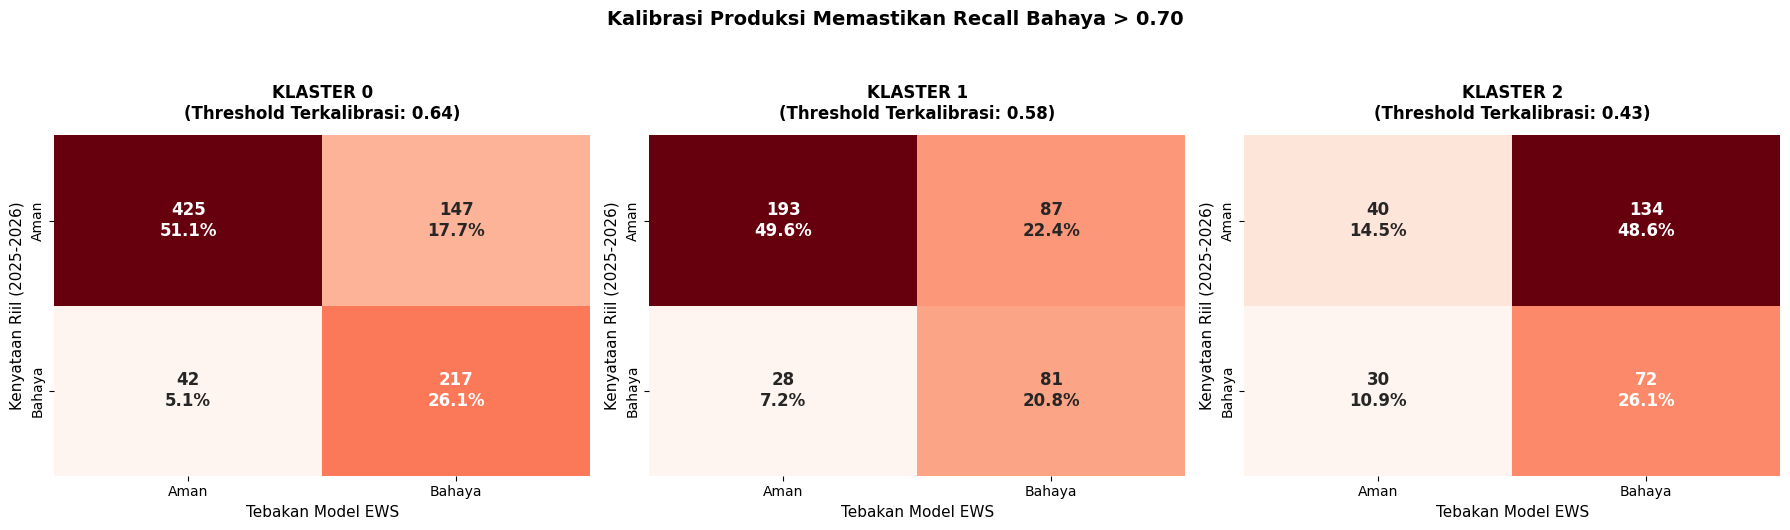

In [25]:
print("\n" + "="*80)
print("[STEP 6] VISUALISASI CONFUSION MATRIX (SINKRONISASI FINAL PRODUKSI)")
print("="*80)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for cluster_id in range(3):
    y_test = cluster_data[cluster_id]['y_test']
    X_test = cluster_data[cluster_id]['X_test']
    model = trained_models[cluster_id]['model']
    
    opt_thresh = calibrated_thresholds[cluster_id] 
    
    test_proba = model.predict_proba(X_test)[:, 1]
    y_pred_test = (test_proba >= opt_thresh).astype(int)
    
    cm = confusion_matrix(y_test, y_pred_test)
    
    group_counts = [f"{value}" for value in cm.flatten()]
    group_percentages = [f"{value:.1%}" for value in cm.flatten()/np.sum(cm)]
    labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_counts, group_percentages)]
    labels = np.asarray(labels).reshape(2,2)
    
    sns.heatmap(cm, annot=labels, fmt='', cmap='Reds', cbar=False, ax=axes[cluster_id], 
                annot_kws={"size": 12, "fontweight": "bold"})
    
    axes[cluster_id].set_title(f'KLASTER {cluster_id}\n(Threshold Terkalibrasi: {opt_thresh:.2f})', 
                               fontsize=12, fontweight='bold', pad=12)
    axes[cluster_id].set_xlabel('Tebakan Model EWS', fontsize=11)
    axes[cluster_id].set_ylabel('Kenyataan Riil (2025-2026)', fontsize=11)
    axes[cluster_id].xaxis.set_ticklabels(['Aman', 'Bahaya'])
    axes[cluster_id].yaxis.set_ticklabels(['Aman', 'Bahaya'])

plt.suptitle('Kalibrasi Produksi Memastikan Recall Bahaya > 0.70', 
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### Tampilkan Hasil MLflow Langsung di Dalam Notebook

In [26]:
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support
import mlflow

print("============================================================")
print("TABEL REKAPITULASI PERFORMA & ARSITEKTUR FINAL")
print("============================================================")

hasil_akhir = []

# Buka satu sesi catatan khusus di MLflow untuk Ujian Akhir
with mlflow.start_run(run_name="EVALUASI_FINAL_DOSEN_2025_2026"):
    
    for cluster_id in range(3):
        model = trained_models[cluster_id]['model']
        opt_thresh = calibrated_thresholds[cluster_id] 
        
        params = model.get_params()
        best_depth = params.get('max_depth')
        best_lr = params.get('learning_rate')
        best_weight = params.get('scale_pos_weight')
        
        X_test = cluster_data[cluster_id]['X_test']
        y_test = cluster_data[cluster_id]['y_test']
        
        test_proba = model.predict_proba(X_test)[:, 1]
        y_pred = (test_proba >= opt_thresh).astype(int)
        
        precision, recall, f1, support = precision_recall_fscore_support(
            y_test, y_pred, labels=[1], zero_division=0
        )
        
        # 1. TULIS METRIK MASA DEPAN KE MLFLOW
        mlflow.log_metric(f"Cluster_{cluster_id}_Test_Recall", recall[0])
        mlflow.log_metric(f"Cluster_{cluster_id}_Test_F1", f1[0])
        
        hasil_akhir.append({
            'Klaster Wilayah': f'Cluster {cluster_id}',
            'Max Depth': best_depth,
            'Learning Rate': best_lr,
            'Bobot Penalti': round(best_weight, 2),
            'Threshold Siaga': round(opt_thresh, 2),
            'Recall (Bahaya)': round(recall[0], 3),
            'Precision': round(precision[0], 3),
            'F1-Score': round(f1[0], 3),
            'Support': support[0]
        })

    df_bukti_sidang = pd.DataFrame(hasil_akhir)
    
    # 2. SIMPAN TABEL FISIK INI KE DALAM MLFLOW SEBAGAI ARTIFAK
    df_bukti_sidang.to_csv("Tabel_Bukti_Sidang_2025_2026.csv", index=False)
    mlflow.log_artifact("Tabel_Bukti_Sidang_2025_2026.csv")

display(df_bukti_sidang)
print("\n✓ SUKSES: Metrik ujian masa depan dan file CSV tabel ini telah dikirim ke MLflow!")

TABEL REKAPITULASI PERFORMA & ARSITEKTUR FINAL


,Klaster Wilayah,Max Depth,Learning Rate,Bobot Penalti,Threshold Siaga,Recall (Bahaya),Precision,F1-Score,Support
0,Cluster 0,3,0.01,9.14,0.64,0.838,0.596,0.697,259
1,Cluster 1,3,0.01,7.28,0.58,0.743,0.482,0.585,109
2,Cluster 2,3,0.01,7.32,0.43,0.706,0.350,0.468,102



✓ SUKSES: Metrik ujian masa depan dan file CSV tabel ini telah dikirim ke MLflow!
